# How well do the Benelux impact heads fit?

Six **quantile LightGBM** heads (plus a shallow CART explainer for habitat) map an infrastructure treatment to physical outcomes. This notebook scores the **saved artifacts** on a **held-out test split** that was not used for early stopping.

It does **not** evaluate the LLM narrator. Labels are a **synthetic recipe** (type priors, distance decay, neighbors, weather when available, noise), so a tight fit means the boosters recovered that recipe — not that they predict field measurements.

Reported numbers use the same quantile sort and nonnegative clamps as `POST /infer`. Quantile-crossing is measured **before** that sort.

Heads: `habitatHa`, `riverTempC`, `vegStress`, `energyIdx`, `jobsFte`, `tco2e`. Each has p10 / p50 / p90.

In [1]:
from pathlib import Path
import json
import sys

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import mean_absolute_error, r2_score

HERE = Path.cwd().resolve()
for candidate in (HERE / "src", HERE / "models" / "src", HERE.parent / "models" / "src"):
    if (candidate / "impact_models").is_dir():
        sys.path.insert(0, str(candidate))
        break

from impact_models.features import FEATURE_COLUMNS, TYPE_INDEX
from impact_models.generate import generate_frame
from impact_models.outputs import HEADS, QUANTILE_ALPHAS, apply_api_quantiles_arrays, crossing_rate, median_abs_error, pinball_loss
from impact_models.train import split_indices
from impact_models import paths

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
    "figure.dpi": 110,
})
PALETTE = ["#1b4f72", "#148f77", "#b9770e", "#6c3483", "#922b21", "#1a5276"]
TYPE_NAMES = {v: k for k, v in TYPE_INDEX.items()}
COUNTRY_NAMES = {0: "NL", 1: "BE", 2: "LU"}
UNITS = {
    "habitatHa": "ha",
    "riverTempC": "°C",
    "vegStress": "index",
    "energyIdx": "index",
    "jobsFte": "FTE",
    "tco2e": "tCO2e/year",
}
print("artifacts", paths.ARTIFACTS_DIR)
print("features", len(FEATURE_COLUMNS))

artifacts C:\Users\skous\SpaceX-Hackathon\ai\models\artifacts
features 38


## Rebuild the train / val / test split

Training uses `seed=7` and a 70 / 15 / 15 split. Early stopping saw **val** only. This notebook scores **test** after the API output transform. `training_summary.json` lists source counts, missing files, and constant features.

In [2]:
recorded = json.loads((paths.ARTIFACTS_DIR / "metrics.json").read_text(encoding="utf-8"))
summary_path = paths.ARTIFACTS_DIR / "training_summary.json"
summary = json.loads(summary_path.read_text(encoding="utf-8")) if summary_path.exists() else {}
n = int(recorded.get("n", 6000))
seed = 7

frame = generate_frame(n=n, seed=seed, include_observations=True)
idx_train, idx_val, idx_test = split_indices(frame, seed=seed)
test = frame.iloc[idx_test].reset_index(drop=True)
x_test = test[list(FEATURE_COLUMNS)].to_numpy(dtype=float)

boosters = {}
for head in HEADS:
    for q in ("p10", "p50", "p90"):
        boosters[f"{head}_{q}"] = lgb.Booster(model_file=str(paths.BOOSTERS_DIR / f"{head}_{q}.txt"))
cart = joblib.load(paths.ARTIFACTS_DIR / "habitat_cart.joblib")

raw_preds = {}
preds = {}
for head in HEADS:
    raw_preds[head] = {q: np.asarray(boosters[f"{head}_{q}"].predict(x_test), dtype=float) for q in ("p10", "p50", "p90")}
    p10, p50, p90 = apply_api_quantiles_arrays(head, raw_preds[head]["p10"], raw_preds[head]["p50"], raw_preds[head]["p90"])
    preds[head] = {"p10": p10, "p50": p50, "p90": p90}

print(f"test rows: {len(test)}  |  val rows: {len(idx_val)}  |  train rows: {len(idx_train)}")
print("warehouse flags", recorded.get("fetch"))
print("missing sources", summary.get("missingSources"))
print("source warnings", summary.get("sourceWarnings"))
print("constant features", summary.get("constantFeatures"))

test rows: 900  |  val rows: 901  |  train rows: 4199
warehouse flags {'gbif': True, 'roadkill': True, 'protected_areas': True, 'water': True, 'osm_roads': True, 'open_meteo': True, 'news': False}
missing sources ['news']
source warnings []
constant features ['gbif_castor_fiber', 'gbif_alcedo_atthis', 'gbif_bombina_variegata', 'gbif_alauda_arvensis', 'gbif_podiceps_cristatus', 'gbif_acrocephalus_scirpaceus', 'gbif_lutra_lutra']


## Median MAE, pinball, coverage, crossing

p50 MAE is the median-head error (also the median absolute error). p10 / p90 pinball should be the training objective. Interval coverage is the share of labels inside p10–p90 after sorting and clamps (target near 80%). Crossing is the share of rows where raw p10/p50/p90 were out of order **before** the API sort.

,mae_p50,median_mae,r2_p50,pinball_p10,pinball_p50,pinball_p90,coverage80,mean_width,crossing_before_sort
head,,,,,,,,,
habitatHa,3.941,2.354,0.912,1.245,1.970,1.192,0.803,18.179,0.066
riverTempC,0.064,0.038,0.940,0.015,0.032,0.018,0.744,0.223,0.023
vegStress,0.363,0.237,0.962,0.117,0.181,0.119,0.770,1.795,0.037
energyIdx,0.150,0.091,0.983,0.048,0.075,0.048,0.781,0.693,0.014
jobsFte,0.940,0.522,0.963,0.376,0.470,0.269,0.793,4.926,0.037
tco2e,36.715,22.414,0.989,20.064,18.358,16.395,0.810,313.152,0.047


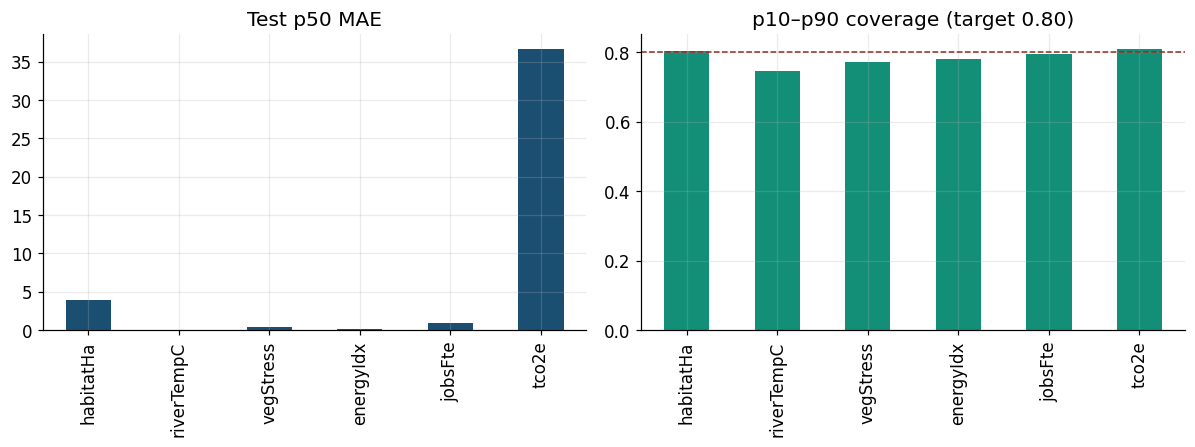

In [3]:
rows = []
for head in HEADS:
    y = test[head].to_numpy(dtype=float)
    raw = raw_preds[head]
    bounded = preds[head]
    row = {
        "head": head,
        "mae_p50": float(mean_absolute_error(y, bounded["p50"])),
        "median_mae": median_abs_error(y, bounded["p50"]),
        "r2_p50": float(r2_score(y, bounded["p50"])),
        "pinball_p10": pinball_loss(y, bounded["p10"], QUANTILE_ALPHAS["p10"]),
        "pinball_p50": pinball_loss(y, bounded["p50"], QUANTILE_ALPHAS["p50"]),
        "pinball_p90": pinball_loss(y, bounded["p90"], QUANTILE_ALPHAS["p90"]),
        "coverage80": float(((y >= bounded["p10"]) & (y <= bounded["p90"])).mean()),
        "mean_width": float(np.mean(bounded["p90"] - bounded["p10"])),
        "crossing_before_sort": crossing_rate(raw["p10"], raw["p50"], raw["p90"]),
    }
    rows.append(row)
metrics = pd.DataFrame(rows).set_index("head").loc[list(HEADS)]
display(metrics.round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
metrics["mae_p50"].plot(kind="bar", ax=axes[0], color=PALETTE[0], title="Test p50 MAE")
metrics["coverage80"].plot(kind="bar", ax=axes[1], color=PALETTE[1], title="p10–p90 coverage (target 0.80)")
axes[1].axhline(0.80, color="#922b21", ls="--", lw=1)
for ax in axes:
    ax.set_xlabel("")
    ax.legend().remove() if ax.get_legend() else None
fig.tight_layout()
plt.show()

## Coverage and width by project type

Overall metrics can hide a failed type. Flag a type if coverage is more than 15 points from 80% or MAE is much worse than the head average.

In [4]:
type_rows = []
types = test["type_idx"].to_numpy(dtype=int)
for head in HEADS:
    y = test[head].to_numpy(dtype=float)
    p10, p50, p90 = preds[head]["p10"], preds[head]["p50"], preds[head]["p90"]
    overall_mae = float(mean_absolute_error(y, p50))
    for type_idx, name in TYPE_NAMES.items():
        mask = types == type_idx
        if not np.any(mask):
            continue
        coverage = float(((y[mask] >= p10[mask]) & (y[mask] <= p90[mask])).mean())
        mae = float(mean_absolute_error(y[mask], p50[mask]))
        type_rows.append({
            "head": head,
            "type": name,
            "n": int(mask.sum()),
            "coverage80": coverage,
            "mae": mae,
            "mean_width": float(np.mean(p90[mask] - p10[mask])),
            "flag": bool(abs(coverage - 0.80) > 0.15 or mae > 3.0 * (overall_mae + 1e-9)),
        })
by_type = pd.DataFrame(type_rows)
display(by_type.pivot(index="type", columns="head", values="coverage80").round(3))
flagged = by_type[by_type["flag"]]
print("flagged type/head cells", len(flagged))
if len(flagged):
    display(flagged)

head,energyIdx,habitatHa,jobsFte,riverTempC,tco2e,vegStress
type,,,,,,
dam,0.812,0.838,0.812,0.667,0.897,0.709
datacentre,0.651,0.862,0.789,0.789,0.780,0.807
highway,0.780,0.789,0.780,0.734,0.835,0.835
housing,0.795,0.821,0.795,0.768,0.777,0.795
industrial,0.774,0.774,0.739,0.757,0.817,0.670
powerline,0.782,0.782,0.782,0.739,0.807,0.706
solar,0.824,0.722,0.870,0.769,0.778,0.852
wind,0.829,0.838,0.784,0.739,0.784,0.802


flagged type/head cells 1


,head,type,n,coverage80,mae,mean_width,flag
31,energyIdx,datacentre,109,0.651376,0.514763,2.442843,True


## Predicted vs actual (median)

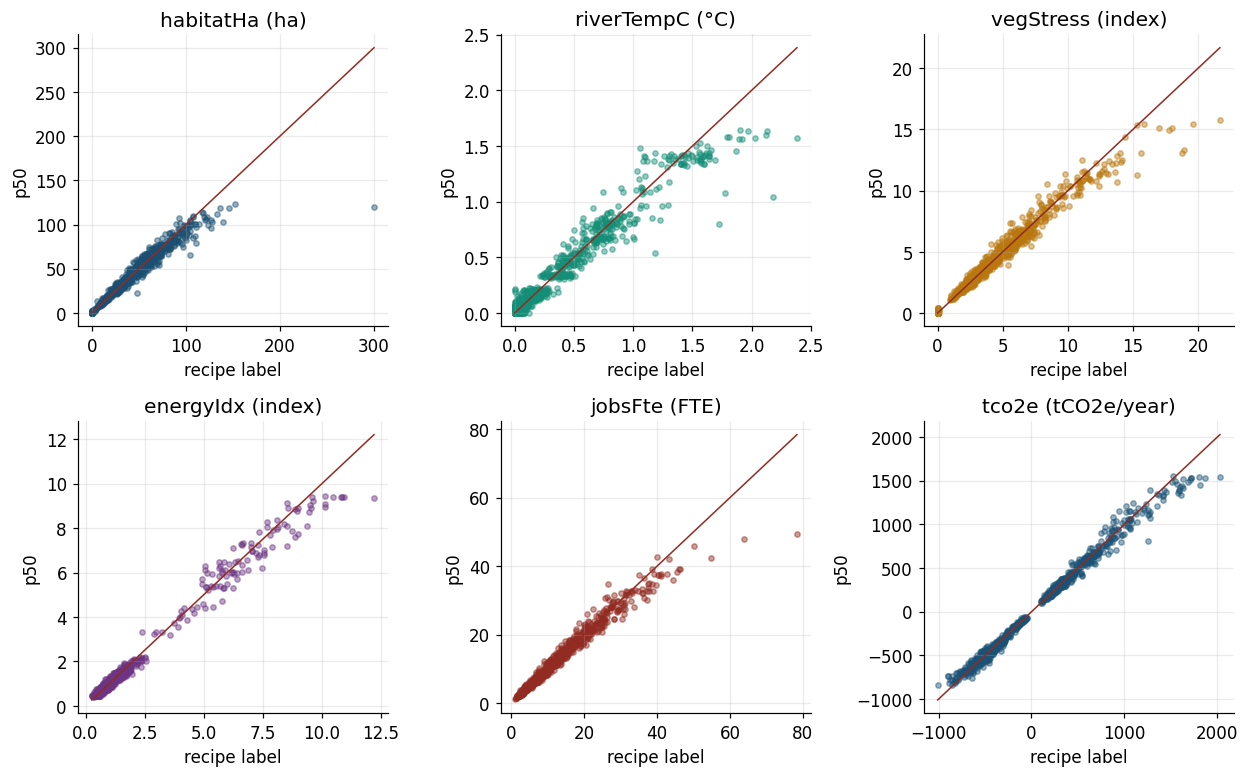

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(11.5, 7.2))
for ax, head in zip(axes.ravel(), HEADS):
    y = test[head].to_numpy(dtype=float)
    yhat = preds[head]["p50"]
    ax.scatter(y, yhat, s=12, alpha=0.45, color=PALETTE[HEADS.index(head) % len(PALETTE)])
    lo, hi = float(min(y.min(), yhat.min())), float(max(y.max(), yhat.max()))
    ax.plot([lo, hi], [lo, hi], color="#922b21", lw=1)
    ax.set_title(f"{head} ({UNITS[head]})")
    ax.set_xlabel("recipe label")
    ax.set_ylabel("p50")
fig.tight_layout()
plt.show()

## Interval ribbon on a slice

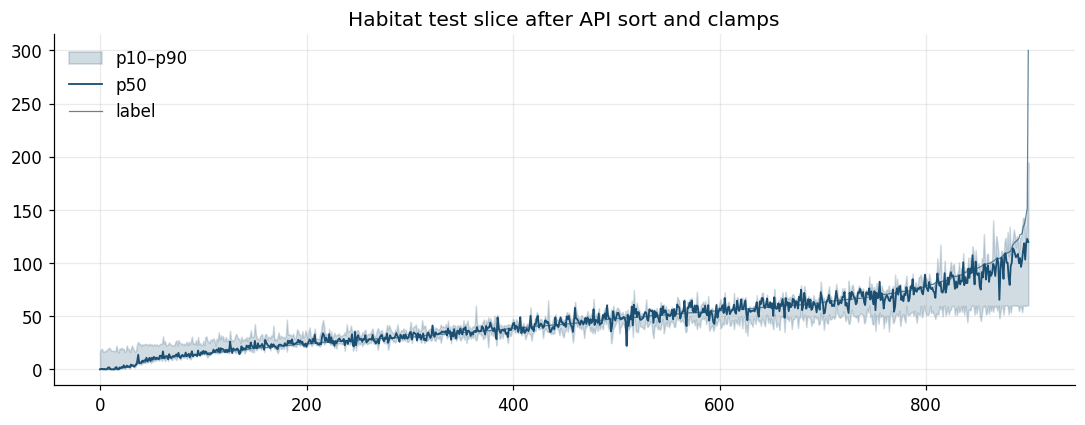

In [6]:
head = "habitatHa"
order = np.argsort(test[head].to_numpy(dtype=float))
y = test[head].to_numpy(dtype=float)[order]
p10, p50, p90 = preds[head]["p10"][order], preds[head]["p50"][order], preds[head]["p90"][order]
xs = np.arange(len(y))
fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(xs, p10, p90, color=PALETTE[0], alpha=0.2, label="p10–p90")
ax.plot(xs, p50, color=PALETTE[0], lw=1.2, label="p50")
ax.plot(xs, y, color="#1a5276", lw=0.8, alpha=0.7, label="label")
ax.set_title("Habitat test slice after API sort and clamps")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## Feature importance

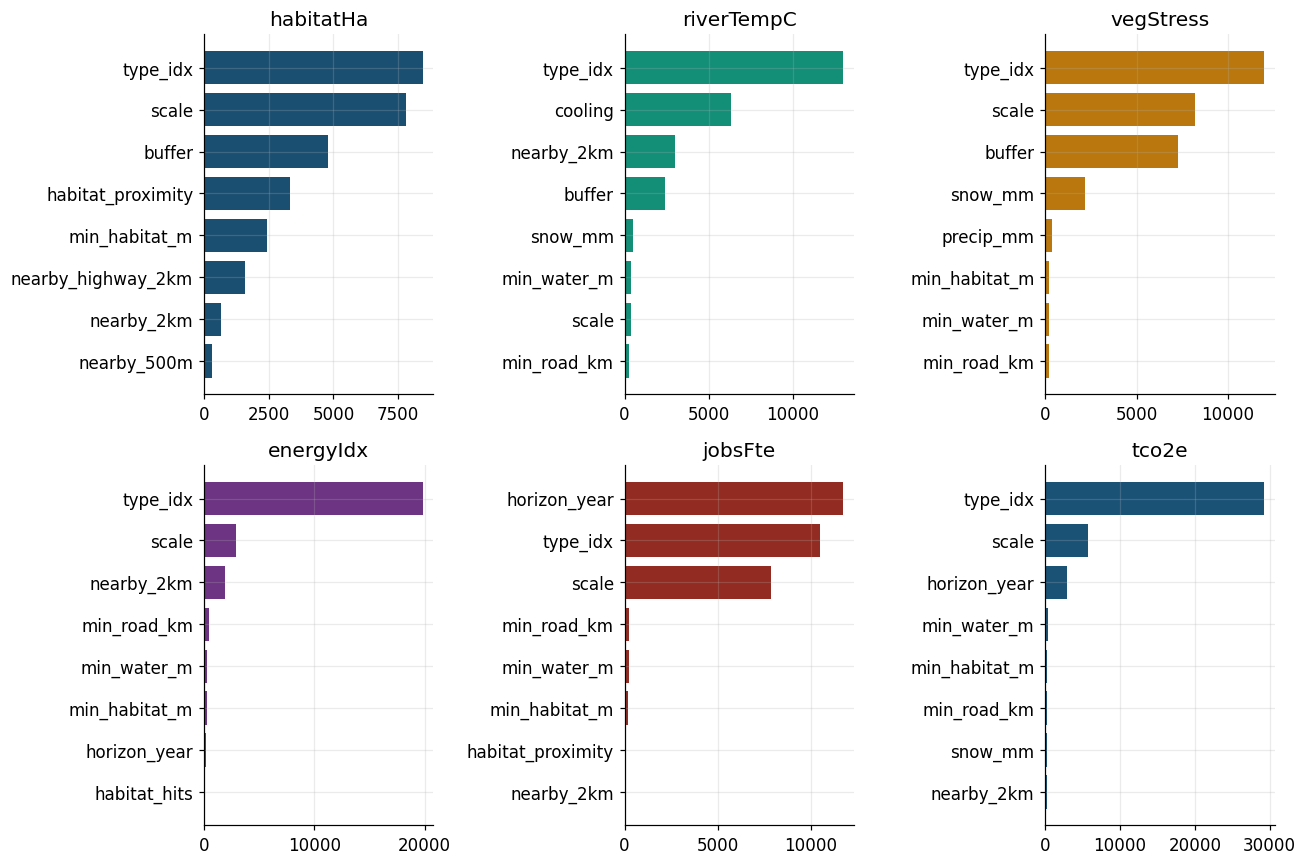

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, head in zip(axes.ravel(), HEADS):
    gain = np.asarray(boosters[f"{head}_p50"].feature_importance(importance_type="gain"), dtype=float)
    order = np.argsort(gain)[-8:]
    ax.barh(np.array(FEATURE_COLUMNS)[order], gain[order], color=PALETTE[HEADS.index(head)])
    ax.set_title(head)
fig.tight_layout()
plt.show()

## CART vs habitat booster

CART is trained to approximate habitat p50, not the raw labels. Agreement on this test split should be close; the explainer text is the submitted sample's path through that tree.

CART vs booster MAE 10.895
CART vs booster R² 0.694
CART vs label MAE 12.3
recorded cartVsBoosterMae 10.940648094094724


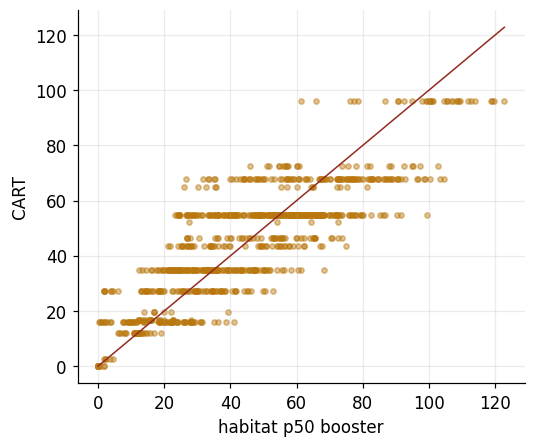

In [8]:
booster_p50 = preds["habitatHa"]["p50"]
cart_hat = cart.predict(x_test)
y = test["habitatHa"].to_numpy(dtype=float)
print("CART vs booster MAE", round(float(mean_absolute_error(booster_p50, cart_hat)), 3))
print("CART vs booster R²", round(float(r2_score(booster_p50, cart_hat)), 3))
print("CART vs label MAE", round(float(mean_absolute_error(y, cart_hat)), 3))
print("recorded cartVsBoosterMae", recorded.get("cartVsBoosterMae"))
fig, ax = plt.subplots(figsize=(5, 4.2))
ax.scatter(booster_p50, cart_hat, s=12, alpha=0.45, color=PALETTE[2])
lo, hi = float(min(booster_p50.min(), cart_hat.min())), float(max(booster_p50.max(), cart_hat.max()))
ax.plot([lo, hi], [lo, hi], color="#922b21", lw=1)
ax.set_xlabel("habitat p50 booster")
ax.set_ylabel("CART")
fig.tight_layout()
plt.show()

## Takeaways

- These checks ask whether the models reproduce the **scenario generator** on a split that was not used for early stopping.
- Coverage should sit near 80% overall and by project type; crossing before sort should be low.
- CART should track the habitat booster more closely than the noisy labels.
- `training_summary.json` should show GBIF, roadkill, roads, and weather with usable variation when collector files are present.
- Real maps in `data/` do not make `scenarioEstimate` a measured impact.